# 模拟光变与显著性分析教学 notebook

这个 notebook 的目标是用一条当前主流程中的 **WCDA weekly light curve**，演示两件事：

1. 如何调用项目代码库，少量生成模拟光变；
2. 为什么要这样做，以及如何利用项目里已经批量生成好的模拟样本库做显著性分析。

在 blazar 的光变分析里，时频图上出现亮区并不自动等于真实 QPO。因为红噪声、有限时间长度、采样窗口和边界效应都可能制造“看起来很像周期”的峰。也正因为这样，项目里才需要用 Emmanoulopoulos 路线构造零假设模拟：先让模拟尽量匹配观测光变的统计性质，再问“在没有真实 QPO 的情况下，类似甚至更强的峰常不常出现”。

这个 notebook 分为两条线：

- 前半部分只生成十几条模拟，用来教学展示“怎么调用模块、输入输出是什么”；
- 后半部分加载项目里已经保存好的大规模 HDF5 模拟库，用它来做真正的显著性比较。

这里重点是**方法展示**，不是论文版最终统计结果。因此本 notebook 保留 WCDA 主线里最成熟、最清晰的 **GWS pre-trial significance** 演示，而不把 archive notebook 里更重、更复杂的二维 local contour 和 WWZ 显著性整套都搬过来。

## 1. 环境与依赖导入

In [1]:
from pathlib import Path
import ast
import json
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycwt as wavelet
from scipy.signal import find_peaks, welch
from scipy.stats import gamma, norm
from tqdm.auto import tqdm


def locate_project_root(markers=("data", "notebooks", "src")):
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {cwd}")


PROJECT_ROOT = locate_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.project_paths import WCDA_RAW_DIR, WCDA_SIM_DIR
from simulation.generate_wcda_weekly_sims import (
    DEFAULT_CSV,
    DEFAULT_OUTPUT,
    build_lc_obs,
    clean_obs,
    load_wcda_excess_csv,
    one_sim,
)

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DEFAULT_CSV =', DEFAULT_CSV)
print('DEFAULT_OUTPUT =', DEFAULT_OUTPUT)

PROJECT_ROOT = /mnt/mydisk/server/projects/QPO
DEFAULT_CSV = /mnt/mydisk/server/projects/QPO/data/raw/wcda/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv
DEFAULT_OUTPUT = /mnt/mydisk/server/projects/QPO/data/simulations/wcda/wcda_weekly_sims_full.h5


## 2. 读取观测数据

这里优先使用当前主分析主线中的 **WCDA weekly binned CSV**。之所以选它，是因为：

- 当前项目已经为它建立了完整的模拟脚本和 HDF5 模拟库；
- 之前的 WCDA notebook 也已经形成了比较稳定的 CWT / GWS 显著性分析流程；
- 它很适合做“模拟输入是什么、显著性比较怎么做”的教学展示。

In [2]:
WCDA_CSV = DEFAULT_CSV if DEFAULT_CSV.exists() else next(sorted(WCDA_RAW_DIR.glob('*.csv')))

# 这里用“原始 CSV + 明确的误差近似”重新构造观测光变，便于后面教学解释每个量的含义。
df_wcda = pd.read_csv(WCDA_CSV, comment='#')
df_wcda.columns = [col.strip() for col in df_wcda.columns]
for col in ['n_on', 'n_bkg', 'n_off']:
    df_wcda[col] = df_wcda[col].apply(ast.literal_eval).apply(lambda values: np.asarray(values, dtype=float))


def compute_wcda_products(row):
    n_on = row['n_on']
    n_bkg = row['n_bkg']
    n_off = row['n_off']
    tobs = float(row['tobs'])

    excess = n_on - n_bkg
    excess_counts = float(np.sum(excess))
    flux_excess = excess_counts / tobs

    # 这里沿用项目中现有 notebook 的一个简单统计误差近似，主要用于作图和 WWZ 清洗。
    alpha = np.divide(n_bkg, n_off, out=np.zeros_like(n_bkg, dtype=float), where=n_off > 0)
    sigma_bin = np.sqrt(np.clip(n_on + np.square(alpha) * n_off, 0.0, None))
    flux_excess_err = float(np.sqrt(np.sum(np.square(sigma_bin))) / tobs)

    return pd.Series({
        'excess_counts': excess_counts,
        'flux_excess': flux_excess,
        'flux_excess_err': flux_excess_err,
    })


df_wcda = df_wcda.join(df_wcda.apply(compute_wcda_products, axis=1))
df_wcda = df_wcda.sort_values('mjd').reset_index(drop=True)
mask = (
    np.isfinite(df_wcda['mjd'])
    & np.isfinite(df_wcda['flux_excess'])
    & np.isfinite(df_wcda['flux_excess_err'])
    & (df_wcda['flux_excess_err'] > 0)
)
df_wcda = df_wcda.loc[mask].copy().reset_index(drop=True)

t_mjd = df_wcda['mjd'].to_numpy(dtype=float)
flux_obs = df_wcda['flux_excess'].to_numpy(dtype=float)
flux_err_obs = df_wcda['flux_excess_err'].to_numpy(dtype=float)
dt_days = float(np.median(np.diff(t_mjd)))

print('WCDA_CSV =', WCDA_CSV)
print('rows =', len(df_wcda))
print('columns =', list(df_wcda.columns))
print('MJD range =', float(t_mjd.min()), '->', float(t_mjd.max()))
print('median cadence [day] =', dt_days)
print(df_wcda[['name', 'mjd', 'flux_excess', 'flux_excess_err']].head())
print(df_wcda[['flux_excess']].describe().T)

WCDA_CSV = /mnt/mydisk/server/projects/QPO/data/raw/wcda/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv
rows = 244
columns = ['name', 'mjd', 'n_on', 'n_bkg', 'n_off', 'tobs', 'excess_counts', 'flux_excess', 'flux_excess_err']
MJD range = 59284.33328206009 -> 60983.58347916683
median cadence [day] = 6.999996295890014
                    name           mjd  flux_excess  flux_excess_err
0  2021-03-08_2021-03-14  59284.333282     0.008311         0.001325
1  2021-03-15_2021-03-21  59291.166555     0.008067         0.001269
2  2021-03-22_2021-03-28  59298.166398     0.005751         0.001140
3  2021-03-29_2021-04-04  59305.166138     0.007081         0.001390
4  2021-04-05_2021-04-11  59312.166027     0.005188         0.001155
             count      mean       std       min       25%      50%     75%  \
flux_excess  244.0  0.007748  0.005625 -0.000285  0.003598  0.00653  0.0105   

                 max  
flux_excess  0.02974  


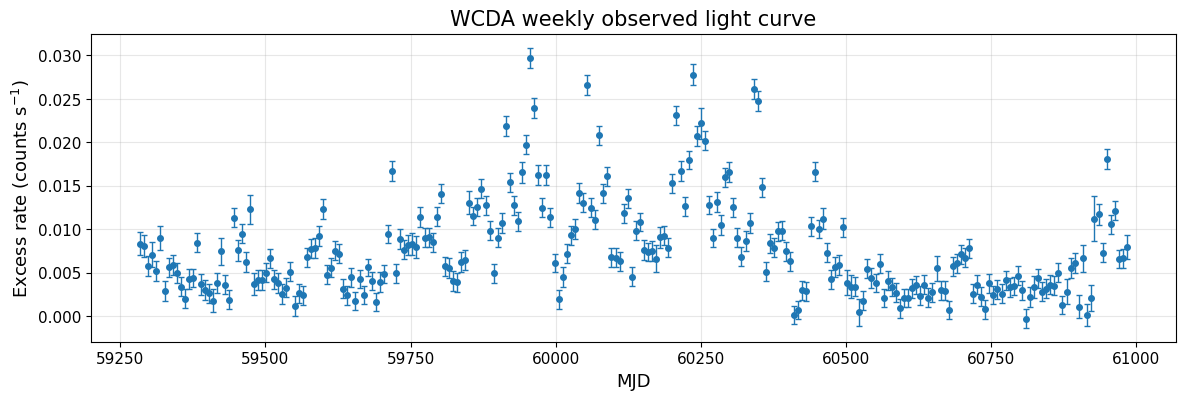

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.errorbar(
    t_mjd,
    flux_obs,
    yerr=flux_err_obs,
    fmt='o',
    ms=4,
    capsize=2,
    elinewidth=1,
)
ax.set_xlabel('MJD')
ax.set_ylabel('Excess rate (counts s$^{-1}$)')
ax.set_title('WCDA weekly observed light curve')
plt.show()

这条真实光变就是后续模拟要尽量去匹配的目标对象。项目的思路不是“凭空制造一批随机数”，而是先把观测时序当作母体，拟合它的 PDF/PSD，再从这个母体上采样出一批“没有真实 QPO、但统计性质尽量接近观测”的零假设光变。

## 3. 为什么要做模拟

这一步的物理和统计动机非常重要：

- blazar 光变通常带有明显红噪声，长时间尺度上自然更容易出现大幅起伏；
- CWT 或 WWZ 图上的亮区，有可能只是红噪声涨落，而不是稳定的真实周期；
- 光变长度有限，边界附近还会受到 COI（cone of influence）影响；
- 观测采样并不完美，窗口函数本身也会制造伪峰。

因此，单看“图上有一个亮斑”并不能回答它是不是 QPO。模拟要回答的问题是：

> 如果真实世界里根本没有额外 QPO，只有和观测相似的红噪声背景，那么像现在这么强的峰，出现的概率到底有多大？

当前项目采用的少量/批量模拟路线，来自已经整理好的 **Emmanoulopoulos** 实现和 `src/simulation/generate_wcda_weekly_sims.py` 脚本。下面先用它做一个小规模演示。

## 4. 演示：如何调用代码库生成少量模拟光变

In [4]:
# 这里直接复用项目现成模块中的辅助函数，而不是在 notebook 里重写一套模拟逻辑。
# 这样可以让演示过程和正式批量生产脚本保持一致。

df_for_sim = load_wcda_excess_csv(WCDA_CSV)
t_clean, flux_clean = clean_obs(df_for_sim)
lc_obs, dt_sim = build_lc_obs(t_clean, flux_clean)

# Emmanoulopoulos 采样通常会先拟合观测光变的 PSD / PDF，后续 sample_from_lc() 再使用这些信息。
if hasattr(lc_obs, 'fit_PSD'):
    lc_obs.fit_PSD()
if hasattr(lc_obs, 'fit_PDF'):
    lc_obs.fit_PDF()

N_DEMO = 12
BASE_SEED = 20250415

demo_results = [one_sim(i, lc_obs, len(t_clean), BASE_SEED) for i in range(N_DEMO)]
demo_indices = np.array([item[0] for item in demo_results], dtype=int)
demo_seeds = np.array([item[1] for item in demo_results], dtype=np.uint32)
demo_flux_sims = np.vstack([item[2] for item in demo_results]).astype(float)

print('lc_obs length =', len(t_clean))
print('demo_flux_sims shape =', demo_flux_sims.shape)
print('demo indices =', demo_indices)
print('demo seeds =', demo_seeds)
print('first sim, first 10 points =')
print(np.round(demo_flux_sims[0, :10], 6))

lc_obs length = 244
demo_flux_sims shape = (12, 244)
demo indices = [ 0  1  2  3  4  5  6  7  8  9 10 11]
demo seeds = [20290274 21290277 22290280 23290283 24290286 25290289 26290292 27290295
 28290298 29290301 30290304 31290307]
first sim, first 10 points =
[0.005098 0.000121 0.       0.000415 0.001254 0.003247 0.001277 0.001689
 0.000455 0.001254]


上面这个单元展示的是“项目里到底怎么调用模拟模块”的最短路径：

- 输入：观测光变 `lc_obs`；
- 中间步骤：在 `lc_obs` 上拟合 PSD / PDF；
- 输出：若干条与观测时间轴长度一致的模拟 flux 数组。

这里故意只生成 `12` 条，目的是让调用过程一眼能看懂。真正正式分析时，并不是靠这 12 条来做统计，而是靠后面要读取的批量 HDF5 模拟库。

## 5. 可视化这些少量模拟光变

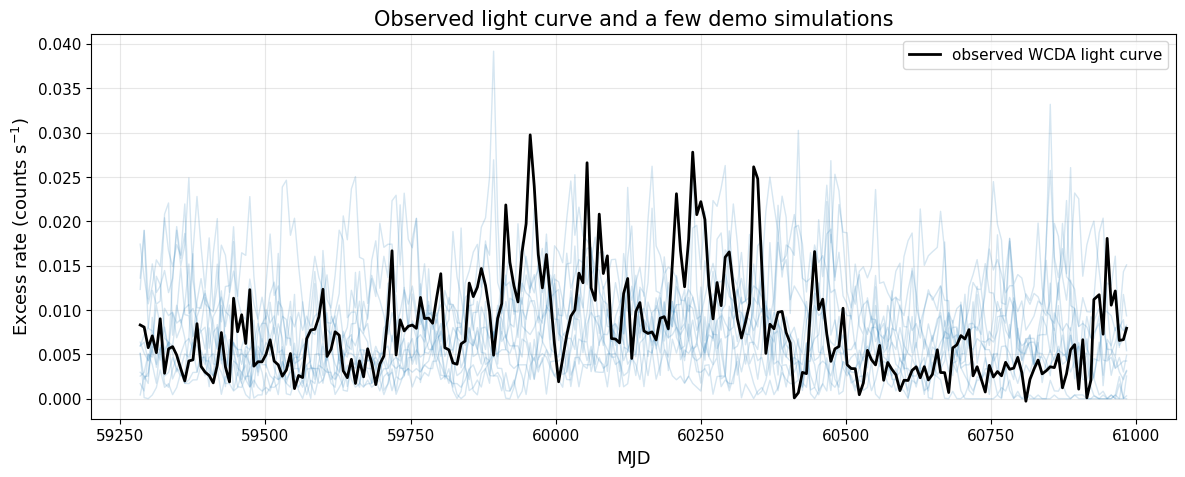

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
for sim in demo_flux_sims:
    ax.plot(t_clean, sim, color='tab:blue', alpha=0.18, lw=1)
ax.plot(t_mjd, flux_obs, color='black', lw=2.0, label='observed WCDA light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Excess rate (counts s$^{-1}$)')
ax.set_title('Observed light curve and a few demo simulations')
ax.legend()
plt.show()

这一步的作用主要是“看形态”。你会发现：

- 模拟曲线整体波动幅度和观测在同一个量级；
- 每条实现都不同，不会逐点复刻真实数据；
- 这正是零假设模拟想要的效果：保留总体随机特征，但不保留具体某一条 realization 的偶然峰。

## 6. 加载项目里已经生成好的大规模模拟数据

In [6]:
SIM_H5 = DEFAULT_OUTPUT if DEFAULT_OUTPUT.exists() else next(sorted(WCDA_SIM_DIR.glob('*.h5')))

with h5py.File(SIM_H5, 'r') as f:
    sim_keys = list(f.keys())
    sim_meta = json.loads(f.attrs['meta_json'])
    t_h5 = np.asarray(f['t_mjd_clean'][:], dtype=float)
    flux_obs_h5 = np.asarray(f['flux_obs_clean'][:], dtype=float)
    flux_sims_shape = f['flux_sims'].shape
    done_count = int(f['done_mask'][:].sum())

print('SIM_H5 =', SIM_H5)
print('datasets =', sim_keys)
print('flux_sims shape =', flux_sims_shape)
print('done_count =', done_count)
print('meta =')
for key in sorted(sim_meta):
    print(f'  {key}: {sim_meta[key]}')

print('time grid match with current notebook =', np.allclose(t_h5, t_clean))
print('obs flux match with current notebook =', np.allclose(flux_obs_h5, flux_clean))

SIM_H5 = /mnt/mydisk/server/projects/QPO/data/simulations/wcda/wcda_weekly_sims_full.h5
datasets = ['done_mask', 'flux_obs_clean', 'flux_sims', 'seed_sims', 't_mjd_clean']
flux_sims shape = (10000, 244)
done_count = 10000
meta =
  Nsim: 10000
  Nt: 244
  base_seed: 123456
  created: 2026-01-30 16:05:45
  dt_days: 6.999996295890014
  emma_path: /home/server/projects/PQO/mkn421/emmanoulopoulos
  lc_signature: LC(original_time, original_flux, errors=None, tbin=None)
  note: Full simulated light curves saved. original_time passed as Quantity (day).
  obs_csv: /home/server/projects/PQO/mkn421_lhaaso/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv
time grid match with current notebook = True
obs flux match with current notebook = True


这里可以看到，真正正式分析依赖的不是前面临时生成的十几条，而是这个已经保存好的 **HDF5 模拟样本库**。它的好处是：

- 不需要每次重新花很多时间生成上万条模拟；
- notebook 只要负责读取和统计；
- 同一套样本库可以被多个分析 notebook 复用，保证结果的一致性。

## 7. 对真实数据做时频分析

In [7]:
def standardize_flux(flux):
    flux = np.asarray(flux, dtype=float)
    flux = flux - np.nanmean(flux)
    std = np.nanstd(flux)
    if not np.isfinite(std) or std == 0:
        raise ValueError('Flux standard deviation is zero or non-finite.')
    return flux / std


# 这一组 helper 基本沿用 WCDA 主 notebook 的成熟写法。
def compute_cwt(flux, t_axis, *, dj=1/12, mother=None):
    t_axis = np.asarray(t_axis, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = float(np.median(np.diff(t_axis)))
    if mother is None:
        mother = wavelet.Morlet(6)
    s0 = 2.0 * dt
    J = int(np.log2(len(flux) * dt / s0) / dj)

    y = standardize_flux(flux)
    w, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(y, dt, dj=dj, s0=s0, J=J, wavelet=mother)
    power = np.abs(w) ** 2
    period = 1.0 / freqs
    return {
        'dt': dt,
        'dj': dj,
        's0': s0,
        'J': J,
        'mother': mother,
        'power': power,
        'period': period,
        'coi': np.asarray(coi, dtype=float),
    }


def compute_gws(flux, t_axis, *, dj=1/12, mother=None, standardize=True):
    t_axis = np.asarray(t_axis, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = float(np.median(np.diff(t_axis)))
    if mother is None:
        mother = wavelet.Morlet(6)
    s0 = 2.0 * dt
    J = int(np.log2(len(flux) * dt / s0) / dj)

    y = np.asarray(flux, dtype=float)
    if standardize:
        y = standardize_flux(y)

    w, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(y, dt, dj=dj, s0=s0, J=J, wavelet=mother)
    power = np.abs(w) ** 2
    period = 1.0 / freqs
    gws = np.mean(power, axis=1)
    return period, gws


def plot_obs_cwt_summary(t_axis, flux, flux_err, cwt_result, *, period_min=50.0, period_max=600.0):
    period = cwt_result['period']
    power = cwt_result['power']
    coi = cwt_result['coi']
    T, P = np.meshgrid(t_axis, period)
    mask = (period >= period_min) & (period <= period_max)
    gws = np.mean(power, axis=1)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={'width_ratios': [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )

    ax_lc, ax_map, ax_gws = axes
    ax_lc.errorbar(t_axis, flux, yerr=flux_err, fmt='o', ms=4, capsize=2, elinewidth=1)
    ax_lc.set_xlabel('MJD')
    ax_lc.set_ylabel('Excess rate (counts s$^{-1}$)')
    ax_lc.set_title('Observed WCDA light curve')

    im = ax_map.contourf(T[mask, :], P[mask, :], power[mask, :], levels=50, cmap='magma', extend='both')
    coi_clip = np.clip(coi, period_min, period_max)
    ax_map.fill_between(
        t_axis,
        period_max,
        coi_clip,
        where=coi_clip <= period_max,
        color='white',
        alpha=0.5,
        hatch='/',
        edgecolor='0.7',
        linewidth=0.0,
    )
    ax_map.plot(t_axis, coi_clip, color='white', lw=1.5, label='COI')
    ax_map.set_yscale('log')
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel('MJD')
    ax_map.set_ylabel('Period (day)')
    ax_map.set_title('Observed CWT power spectrum')
    ax_map.legend(loc='upper right')
    cbar = fig.colorbar(im, ax=ax_map, pad=0.02)
    cbar.set_label('Power')

    ax_gws.plot(gws, period, color='black', lw=1.6)
    ax_gws.set_xscale('log')
    ax_gws.set_yscale('log')
    ax_gws.set_ylim(period_min, period_max)
    ax_gws.set_xlabel('Global Wavelet Power')
    ax_gws.set_title('Observed GWS')
    plt.setp(ax_gws.get_yticklabels(), visible=False)
    return fig, axes

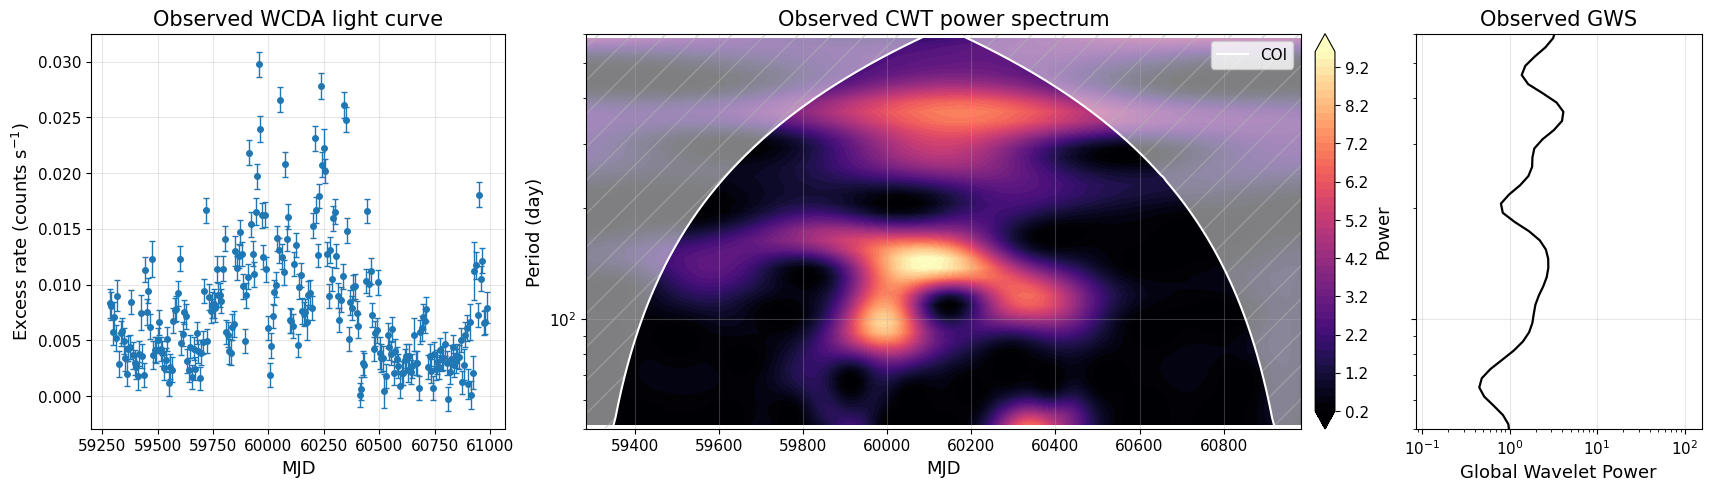

In [8]:
obs_cwt = compute_cwt(flux_obs, t_mjd)
period_obs, gws_obs = compute_gws(flux_obs, t_mjd)
fig, axes = plot_obs_cwt_summary(t_mjd, flux_obs, flux_err_obs, obs_cwt, period_min=50.0, period_max=600.0)
plt.show()

上面这一步给出了观测光变本身的时频结构。真正的显著性问题不是“图上有没有峰”，而是：

> 这些峰放到零假设模拟的背景里，究竟算常见还是算少见？

下面开始对 HDF5 样本库做和观测对应的统计量计算。这里为了保持链条清楚，先只保留项目中最成熟的一条线：**对每个周期上的 GWS 分布做 pre-trial significance**。

## 8. 对大规模模拟样本做同样的分析

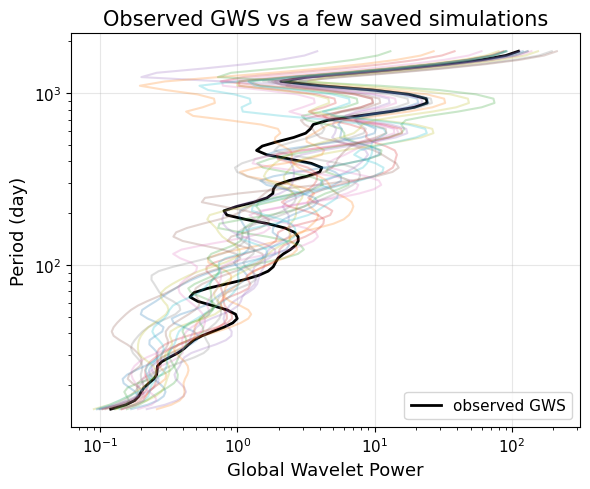

In [9]:
# 先从 HDF5 里随机抽取少量样本，画成多条 GWS 曲线，帮助理解“模拟分布”是什么样子。
N_SHOW = 20
SHOW_SEED = 42

with h5py.File(SIM_H5, 'r') as f:
    rng = np.random.default_rng(SHOW_SEED)
    idx_show = np.sort(rng.choice(f['flux_sims'].shape[0], size=N_SHOW, replace=False))
    flux_show = np.asarray(f['flux_sims'][idx_show], dtype=float)

plt.figure(figsize=(6, 5))
plt.plot(gws_obs, period_obs, 'k', lw=2, label='observed GWS')
for sim_flux in flux_show:
    period_sim, gws_sim = compute_gws(sim_flux, t_mjd)
    plt.plot(gws_sim, period_sim, alpha=0.25)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Global Wavelet Power')
plt.ylabel('Period (day)')
plt.title('Observed GWS vs a few saved simulations')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# 这里使用 HDF5 中全部已经完成的样本库来构建 GWS 背景分布。
# 这一步本身不重新生成模拟，只是把已有模拟逐条做同样的 GWS 统计。
read_chunk = 256
GWS_sims = []
period_ref = None

with h5py.File(SIM_H5, 'r') as f:
    flux_sims_ds = f['flux_sims']
    Nsim_total = flux_sims_ds.shape[0]

    for start in tqdm(range(0, Nsim_total, read_chunk), desc='GWS from saved sims'):
        end = min(Nsim_total, start + read_chunk)
        flux_chunk = np.asarray(flux_sims_ds[start:end], dtype=float)

        for flux_sim in flux_chunk:
            period_sim, gws_sim = compute_gws(flux_sim, t_mjd)
            if period_ref is None:
                period_ref = period_sim
            elif not np.allclose(period_sim, period_ref):
                raise RuntimeError('Period grid mismatch in saved simulations')
            GWS_sims.append(gws_sim)

GWS_sims = np.asarray(GWS_sims, dtype=float)
print('GWS_sims shape =', GWS_sims.shape)

GWS from saved sims:   0%|          | 0/40 [00:00<?, ?it/s]

GWS_sims shape = (10000, 84)


现在我们已经有了两类量：

- 观测光变的 `gws_obs(period)`；
- 零假设模拟样本的 `GWS_sims[isim, period]`。

后面的显著性分析，就是把 `gws_obs` 放到 `GWS_sims` 的分布里，看看观测值在该分布中处于什么位置。

## 9. 显著性分析展示

In [11]:
# 这里沿用旧 WCDA notebook 中较成熟的思路：
# 用 Gamma(≈scaled chi-square) 去拟合每个 period 上的 GWS 模拟分布，得到 pre-trial 阈值曲线。
sigmas = np.array([1, 3, 5], dtype=float)
q = norm.cdf(sigmas)

thr_1s = np.empty(GWS_sims.shape[1])
thr_3s = np.empty(GWS_sims.shape[1])
thr_5s = np.empty(GWS_sims.shape[1])
k_eff = np.empty(GWS_sims.shape[1])

for j in range(GWS_sims.shape[1]):
    x = GWS_sims[:, j]
    x = x[np.isfinite(x)]
    x = x[x > 0]

    try:
        a_hat, _, scale_hat = gamma.fit(x, floc=0)
        if (not np.isfinite(a_hat)) or (not np.isfinite(scale_hat)) or (a_hat <= 0) or (scale_hat <= 0):
            raise ValueError('bad gamma parameters')
    except Exception:
        mu = x.mean()
        sd = x.std(ddof=1)
        a_hat = (mu / sd) ** 2
        scale_hat = (sd ** 2) / mu

    k_eff[j] = 2.0 * a_hat
    thr_1s[j], thr_3s[j], thr_5s[j] = gamma.ppf(q, a=a_hat, loc=0, scale=scale_hat)

print('median effective chi-square dof =', float(np.median(k_eff)))

median effective chi-square dof = 8.64692109920092


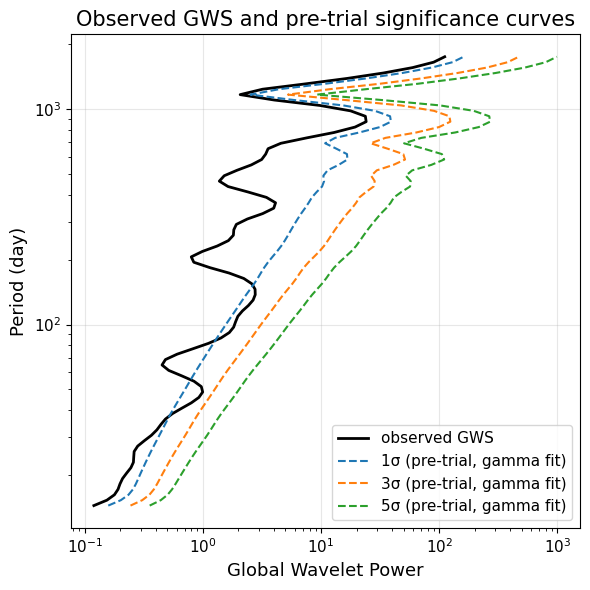

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(gws_obs, period_obs, 'k', lw=2, label='observed GWS')
plt.plot(thr_1s, period_obs, '--', label='1σ (pre-trial, gamma fit)')
plt.plot(thr_3s, period_obs, '--', label='3σ (pre-trial, gamma fit)')
plt.plot(thr_5s, period_obs, '--', label='5σ (pre-trial, gamma fit)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Global Wavelet Power')
plt.ylabel('Period (day)')
plt.title('Observed GWS and pre-trial significance curves')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# 再挑一个观测主峰，直接看“观测值在模拟分布里排第几”。
# 这是最直观的一种教学展示方式。
period_mask = (period_obs >= 50.0) & (period_obs <= 600.0)
peak_idx_within = np.nanargmax(np.where(period_mask, gws_obs, np.nan))
peak_period = float(period_obs[peak_idx_within])
peak_power = float(gws_obs[peak_idx_within])
peak_dist = np.asarray(GWS_sims[:, peak_idx_within], dtype=float)
peak_p_empirical = (np.sum(peak_dist >= peak_power) + 1) / (len(peak_dist) + 1)
peak_sigma_empirical = float(norm.isf(np.clip(peak_p_empirical, 1e-300, 1 - 1e-12)))

print(f'candidate peak period = {peak_period:.2f} day')
print(f'observed peak GWS = {peak_power:.4f}')
print(f'empirical pre-trial p = {peak_p_empirical:.6g}')
print(f'equivalent one-sided sigma = {peak_sigma_empirical:.3f}')

candidate peak period = 367.33 day
observed peak GWS = 4.1242
empirical pre-trial p = 0.50135
equivalent one-sided sigma = -0.003


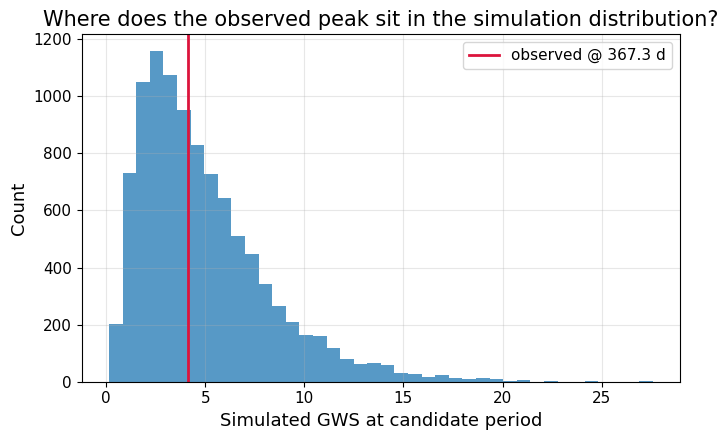

In [14]:
plt.figure(figsize=(7, 4.5))
plt.hist(peak_dist, bins=40, alpha=0.75, color='tab:blue')
plt.axvline(peak_power, color='crimson', lw=2, label=f'observed @ {peak_period:.1f} d')
plt.xlabel('Simulated GWS at candidate period')
plt.ylabel('Count')
plt.title('Where does the observed peak sit in the simulation distribution?')
plt.legend()
plt.tight_layout()
plt.show()

## 10. 结果解释

显著性分析真正要回答的是：

- 如果观测峰落在模拟分布的常见范围里，那么它很可能只是红噪声背景中的随机涨落；
- 如果观测峰明显跑到了模拟分布的尾部，才说明这个候选周期值得被更认真地对待。

上面的 `GWS with pre-trial significance` 图和候选周期直方图，其实是在用两种角度讲同一件事：

- 阈值曲线图告诉你“在每个 period 上，大概多高才算少见”；
- 直方图告诉你“某个具体候选峰，在零假设分布里到底罕不罕见”。

需要强调的是，这类显著性并不是“与模型无关”的绝对真理。它依赖于：

- 你采用了什么零假设；
- 模拟是否真的复现了观测的统计性质；
- 你比较的统计量到底是 local power、GWS，还是某种 global maximum。

因此，这里的结果更适合作为“候选峰是否值得继续追踪”的统计背景，而不是一句话就能下结论的最终裁决。

## 11. notebook 末尾总结

这个教学 notebook 做了四件事：

- 展示了如何直接调用项目代码库中的模拟模块，少量生成 WCDA 模拟光变；
- 画出了真实光变和少量模拟光变的形态对比；
- 加载了项目中已经批量生成好的 `wcda_weekly_sims_full.h5` 模拟样本库；
- 用这些模拟背景对观测 GWS 做了 pre-trial 显著性比较，并给出了一个候选峰在模拟分布中的位置示例。

再次强调：前面那十几条模拟只是**教学演示**，真正正式的显著性分析依赖的是后面读取的大规模 HDF5 模拟库。更复杂的二维 local significance、WWZ 显著性原型和其他实验性统计步骤，仍然保留在 archive notebook 中，适合在这条主线弄清楚之后再回头看。